# Proyek Analisis Data: Air Quality Data Analysis
- **Nama:** Mars
- **Email:** marselloormanda@gmail.com
- **ID Dicoding:** user1603

## Menentukan Pertanyaan Bisnis

Berikut adalah dua pertanyaan bisnis dengan menerapkan prinsip SMART:

### Pertanyaan Bisnis Baru

1.  **Tren Konsentrasi PM2.5 Bulanan per Stasiun (2013-2017):**
    Untuk setiap stasiun pengamatan (`Dingling`, `Dongsi`, `Gucheng`), bagaimana tren rata-rata konsentrasi PM2.5 bulanan (`PM2.5`) berubah dari tahun 2013 hingga 2017, dan apakah ada pola musiman (misalnya, peningkatan di bulan-bulan tertentu) yang konsisten terlihat di antara stasiun-stasiun tersebut?
    *   **Specific:** Menanyakan tren rata-rata PM2.5 bulanan per stasiun.
    *   **Measurable:** Rata-rata konsentrasi PM2.5 (nilai numerik).
    *   **Achievable:** Data `year`, `month`, `PM2.5`, dan `station` tersedia.
    *   **Relevant:** Penting untuk pemahaman kualitas udara dan kebijakan lingkungan.
    *   **Time-bound:** Dari tahun 2013 hingga 2017.

2.  **Pengaruh Kecepatan Angin Terhadap PM10 di Stasiun Dongsi Berdasarkan Musim (2013-2017):**
    Di stasiun `Dongsi`, bagaimana pengaruh kecepatan angin (`WSPM`) terhadap tingkat polusi PM10 (`PM10`) secara harian, dan apakah ada perbedaan signifikan dalam hubungan ini antara musim kemarau (Mei-September) dan musim hujan (Oktober-April) dari tahun 2013 hingga 2017?
    *   **Specific:** Menanyakan hubungan antara kecepatan angin dan PM10 secara harian di stasiun `Dongsi`, serta variasinya antar musim.
    *   **Measurable:** Korelasi/hubungan antara `WSPM` dan `PM10` (nilai numerik), perbandingan rata-rata.
    *   **Achievable:** Data `day`, `month`, `year`, `WSPM`, `PM10`, dan `station` tersedia.
    *   **Relevant:** Membantu dalam pemodelan prediksi polusi dan strategi mitigasi.
    *   **Time-bound:** Dari tahun 2013 hingga 2017.

## Import Semua Packages/Library yang Digunakan

In [ ]:
# 1. Library utama untuk manipulasi dan pengolahan data
import pandas as pd

# 2. Library utama untuk pembuatan visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Library tambahan untuk menjaga kerapian output notebook
import warnings

## Penjelasan singkat fungsinya:

1. pandas: Ini adalah pondasi utama kita. Nanti kita akan menggunakannya untuk membaca tabel, menghitung agregasi, dan memanipulasi kolom.

2. matplotlib & seaborn: Ini adalah kanvas dan kuas kita. seaborn dibuat di atas matplotlib untuk menghasilkan grafik berkualitas tinggi dengan kode yang lebih pendek.

3. warnings: Murni untuk estetika agar notebook kamu tetap bersih dan enak dibaca saat di-ulas (review).

## Data Wrangling

### Gathering Data

In [ ]:
# --- TAHAP 1: DATA GATHERING ---

# 1. Menyimpan link dataset ke dalam variabel
url_data = 'https://raw.githubusercontent.com/Marsello-or/CDC_30_Implementing-Air-Quality-Dataset/refs/heads/main/PRSA_Data_20130301-20170228/PRSA_Data_Dingling_20130301-20170228.csv'
url_data_2 = 'https://raw.githubusercontent.com/Marsello-or/CDC_30_Implementing-Air-Quality-Dataset/refs/heads/main/PRSA_Data_20130301-20170228/PRSA_Data_Dongsi_20130301-20170228.csv'
url_data_3 = 'https://raw.githubusercontent.com/Marsello-or/CDC_30_Implementing-Air-Quality-Dataset/refs/heads/main/PRSA_Data_20130301-20170228/PRSA_Data_Gucheng_20130301-20170228.csv'

In [ ]:
df_1 = pd.read_csv(url_data)
df_2 = pd.read_csv(url_data_2)
df_3 = pd.read_csv(url_data_3)

print("--- 5 Baris Pertama DataFrame dari url_data ---")
display(df_1.head())

print("--- 5 Baris Pertama DataFrame dari url_data_2 ---")
display(df_2.head())

print("--- 5 Baris Pertama DataFrame dari url_data_3 ---")
display(df_3.head())

--- 5 Baris Pertama DataFrame dari url_data ---


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,3.0,NaN,200.0,82.0,-2.3,1020.8,-19.7,0.0,E,0.5,Dingling
1,2,2013,3,1,1,7.0,7.0,3.0,NaN,200.0,80.0,-2.5,1021.3,-19.0,0.0,ENE,0.7,Dingling
2,3,2013,3,1,2,5.0,5.0,3.0,2.0,200.0,79.0,-3.0,1021.3,-19.9,0.0,ENE,0.2,Dingling
3,4,2013,3,1,3,6.0,6.0,3.0,NaN,200.0,79.0,-3.6,1021.8,-19.1,0.0,NNE,1.0,Dingling
4,5,2013,3,1,4,5.0,5.0,3.0,NaN,200.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1,Dingling


--- 5 Baris Pertama DataFrame dari url_data_2 ---


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,9.0,9.0,3.0,17.0,300.0,89.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Dongsi
1,2,2013,3,1,1,4.0,4.0,3.0,16.0,300.0,88.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Dongsi
2,3,2013,3,1,2,7.0,7.0,NaN,17.0,300.0,60.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Dongsi
3,4,2013,3,1,3,3.0,3.0,5.0,18.0,NaN,NaN,-1.4,1026.2,-25.5,0.0,N,4.9,Dongsi
4,5,2013,3,1,4,3.0,3.0,7.0,NaN,200.0,84.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Dongsi


--- 5 Baris Pertama DataFrame dari url_data_3 ---


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,6.0,18.0,5.0,NaN,800.0,88.0,0.1,1021.1,-18.6,0.0,NW,4.4,Gucheng
1,2,2013,3,1,1,6.0,15.0,5.0,NaN,800.0,88.0,-0.3,1021.5,-19.0,0.0,NW,4.0,Gucheng
2,3,2013,3,1,2,5.0,18.0,NaN,NaN,700.0,52.0,-0.7,1021.5,-19.8,0.0,WNW,4.6,Gucheng
3,4,2013,3,1,3,6.0,20.0,6.0,NaN,NaN,NaN,-1.0,1022.7,-21.2,0.0,W,2.8,Gucheng
4,5,2013,3,1,4,5.0,17.0,5.0,NaN,600.0,73.0,-1.3,1023.0,-21.4,0.0,WNW,3.6,Gucheng


**Insight:**
- Fungsi pembacaan data (pd.read_csv) berhasil memisahkan setiap nilai ke dalam kolomnya masing-masing dengan tepat. Tidak ada masalah delimiter (pemisah koma) yang menyebabkan beberapa kolom menumpuk menjadi satu, sehingga data dipastikan berbentuk tabel tabular yang rapi.
- Tampilan 5 baris pertama memberikan gambaran wujud konkret dari nilai setiap variabel.
- Data yang tampil selaras dengan judul kolomnya.

### Assessing Data

In [ ]:
dataframes = {'df_1': df_1, 'df_2': df_2, 'df_3': df_3}

for name, df_current in dataframes.items():
    print(f"=== Data Assessment for {name} ===")

    print("\n1. Informasi Struktur dan Tipe Data:")
    df_current.info()
    print("--------------------------------------------------")

    print("\n2. Pengecekan Data Kosong (Missing Values):")
    print(df_current.isna().sum())
    print("--------------------------------------------------")

    print("\n3. Ringkasan Statistik Data Numerik:")
    display(df_current.describe())
    print("\n" + "="*40 + "\n")

=== Data Assessment for df_1 ===

1. Informasi Struktur dan Tipe Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34285 non-null  float64
 6   PM10     34408 non-null  float64
 7   SO2      34334 non-null  float64
 8   NO2      33830 non-null  float64
 9   CO       33052 non-null  float64
 10  O3       33850 non-null  float64
 11  TEMP     35011 non-null  float64
 12  PRES     35014 non-null  float64
 13  DEWP     35011 non-null  float64
 14  RAIN     35013 non-null  float64
 15  wd       34924 non-null  object 
 16  WSPM     35021 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ 

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34285.000000,34408.000000,34334.000000,33830.000000,33052.000000,33850.000000,35011.000000,35014.000000,35011.000000,35013.000000,35021.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,65.989497,83.739723,11.749650,27.585467,904.896073,68.548371,13.686111,1007.760278,1.505495,0.060366,1.853836
std,10122.249256,1.177213,3.448752,8.800218,6.922285,72.267723,79.541685,15.519259,26.383882,903.306220,53.764424,11.365313,10.225664,13.822099,0.752899,1.309808
min,1.000000,2013.000000,1.000000,1.000000,0.000000,3.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-16.600000,982.400000,-35.100000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,14.000000,26.000000,2.000000,9.000000,300.000000,31.000000,3.400000,999.300000,-10.200000,0.000000,1.000000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,41.000000,60.000000,5.000000,19.000000,600.000000,61.000000,14.700000,1007.400000,1.800000,0.000000,1.500000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,93.000000,117.000000,15.000000,38.000000,1200.000000,90.000000,23.300000,1016.000000,14.200000,0.000000,2.300000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,881.000000,905.000000,156.000000,205.000000,10000.000000,500.000000,41.400000,1036.500000,27.200000,52.100000,10.000000




=== Data Assessment for df_2 ===

1. Informasi Struktur dan Tipe Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34314 non-null  float64
 6   PM10     34511 non-null  float64
 7   SO2      34401 non-null  float64
 8   NO2      33463 non-null  float64
 9   CO       31867 non-null  float64
 10  O3       34400 non-null  float64
 11  TEMP     35044 non-null  float64
 12  PRES     35044 non-null  float64
 13  DEWP     35044 non-null  float64
 14  RAIN     35044 non-null  float64
 15  wd       34986 non-null  object 
 16  WSPM     35050 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34314.000000,34511.000000,34401.000000,33463.000000,31867.000000,34400.000000,35044.000000,35044.000000,35044.000000,35044.000000,35050.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,86.194297,110.336742,18.531107,53.699443,1330.069131,57.210637,13.671490,1012.547419,2.447535,0.064020,1.860785
std,10122.249256,1.177213,3.448752,8.800218,6.922285,86.575127,98.219860,22.905655,33.959230,1191.305887,58.033275,11.458418,10.266059,13.810696,0.786282,1.280368
min,1.000000,2013.000000,1.000000,1.000000,0.000000,3.000000,2.000000,0.285600,2.000000,100.000000,0.642600,-16.800000,987.100000,-35.300000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,22.000000,38.000000,4.000000,27.000000,600.000000,12.000000,3.100000,1004.000000,-8.800000,0.000000,1.000000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,61.000000,86.000000,10.000000,47.000000,1000.000000,44.125200,14.600000,1012.200000,3.000000,0.000000,1.500000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,119.000000,151.000000,24.000000,73.000000,1700.000000,81.000000,23.500000,1020.900000,15.000000,0.000000,2.400000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,737.000000,955.000000,300.000000,258.000000,10000.000000,1071.000000,41.100000,1042.000000,28.800000,46.400000,10.500000




=== Data Assessment for df_3 ===

1. Informasi Struktur dan Tipe Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34418 non-null  float64
 6   PM10     34683 non-null  float64
 7   SO2      34557 non-null  float64
 8   NO2      34396 non-null  float64
 9   CO       33663 non-null  float64
 10  O3       34335 non-null  float64
 11  TEMP     35013 non-null  float64
 12  PRES     35014 non-null  float64
 13  DEWP     35013 non-null  float64
 14  RAIN     35021 non-null  float64
 15  wd       34905 non-null  object 
 16  WSPM     35022 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34418.000000,34683.000000,34557.000000,34396.000000,33663.000000,34335.000000,35013.000000,35014.000000,35013.000000,35021.000000,35022.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,83.852089,118.861978,15.366162,55.871075,1323.974423,57.694879,13.864524,1008.829592,2.610442,0.064453,1.343310
std,10122.249256,1.177213,3.448752,8.800218,6.922285,82.796445,96.742626,21.204526,36.473860,1208.957772,57.019587,11.292857,10.103256,13.782991,0.838654,1.151064
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,2.000000,100.000000,0.214200,-15.600000,984.000000,-34.600000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,24.000000,45.000000,2.000000,26.000000,600.000000,10.000000,3.600000,1000.500000,-8.900000,0.000000,0.600000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,60.000000,99.000000,7.000000,50.000000,900.000000,45.000000,14.800000,1008.500000,3.000000,0.000000,1.000000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,115.750000,167.000000,20.000000,79.000000,1600.000000,83.000000,23.500000,1017.000000,15.300000,0.000000,1.800000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,770.000000,994.000000,500.000000,276.000000,10000.000000,450.000000,41.600000,1038.100000,27.400000,41.900000,12.000000


**Insight:**
- **Struktur Data Konsisten:** Ketiga DataFrame (`df_1`, `df_2`, `df_3`) memiliki struktur yang sama (35064 baris, 18 kolom) dan mencakup periode waktu yang sama (2013-2017).
- **Variasi Tipe Data:** Kolom tanggal (`year`, `month`, `day`, `hour`) dan ID (`No`) bertipe integer. Kolom polutan dan meteorologi bertipe float, sedangkan arah angin (`wd`) dan stasiun (`station`) bertipe objek (string).
- **Missing Values Signifikan:** Terdapat *missing values* di banyak kolom polutan (`PM2.5`, `PM10`, `SO2`, `NO2`, `CO`, `O3`) dan meteorologi, yang perlu ditangani sebelum analisis. Jumlah missing values bervariasi antar kolom dan stasiun, dengan `CO` dan `NO2` memiliki jumlah yang paling tinggi di beberapa stasiun.
- **Perbedaan Kualitas Udara antar Stasiun:** Statistik deskriptif menunjukkan bahwa rata-rata konsentrasi polutan berbeda secara substansial di antara tiga stasiun, mengindikasikan variasi kualitas udara di lokasi yang berbeda.

### Cleaning Data

In [ ]:
# 1. Menggabungkan ketiga DataFrame menjadi satu
all_df = pd.concat([df_1, df_2, df_3], ignore_index=True)

print("--- Informasi Gabungan DataFrame setelah Concatenation ---")
display(all_df.info())
print("--------------------------------------------------")

print("--- Missing Values sebelum Penanganan ---")
display(all_df.isna().sum()[all_df.isna().sum() > 0].sort_values(ascending=False))
print("--------------------------------------------------")

# 2. Menangani Missing Values untuk kolom numerik dengan interpolasi (forward fill dan backward fill)
# Kolom numerik yang mungkin memiliki missing values:
# PM2.5, PM10, SO2, NO2, CO, O3, TEMP, PRES, DEWP, RAIN, WSPM

numeric_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
for col in numeric_cols:
    all_df[col] = all_df[col].ffill().bfill() # Menggunakan ffill lalu bfill

# Menangani kolom 'wd' (arah angin) yang bertipe objek. Mengisi dengan modus.
# Karena 'wd' adalah kategorikal, ffill/bfill mungkin tidak sesuai. Modus lebih umum.
if 'wd' in all_df.columns:
    all_df['wd'] = all_df['wd'].fillna(all_df['wd'].mode()[0])

# 3. Menghapus baris yang masih memiliki missing values (jika ada, sebagai langkah terakhir)
initial_rows = len(all_df)
all_df.dropna(inplace=True)
final_rows = len(all_df)

print(f"Jumlah baris sebelum dropna: {initial_rows}")
print(f"Jumlah baris setelah dropna: {final_rows}")
print(f"Jumlah baris yang dihapus: {initial_rows - final_rows}")

print("\n--- Pengecekan Missing Values setelah Penanganan ---")
display(all_df.isna().sum()[all_df.isna().sum() > 0])

# Mengatur ulang indeks setelah penghapusan baris
all_df.reset_index(drop=True, inplace=True)

# Membuat DataFrame baru `df` yang berisi data bersih
df = all_df.copy()
print("\nDataframe `df` telah dibuat dari data gabungan dan telah ditangani missing values-nya.")
print("--- Informasi DataFrame `df` setelah Cleaning ---")
display(df.info())
print("--------------------------------------------------")

--- Informasi Gabungan DataFrame setelah Concatenation ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105192 entries, 0 to 105191
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       105192 non-null  int64  
 1   year     105192 non-null  int64  
 2   month    105192 non-null  int64  
 3   day      105192 non-null  int64  
 4   hour     105192 non-null  int64  
 5   PM2.5    103017 non-null  float64
 6   PM10     103602 non-null  float64
 7   SO2      103292 non-null  float64
 8   NO2      101689 non-null  float64
 9   CO       98582 non-null   float64
 10  O3       102585 non-null  float64
 11  TEMP     105068 non-null  float64
 12  PRES     105072 non-null  float64
 13  DEWP     105068 non-null  float64
 14  RAIN     105078 non-null  float64
 15  wd       104815 non-null  object 
 16  WSPM     105093 non-null  float64
 17  station  105192 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory us

None

--------------------------------------------------
--- Missing Values sebelum Penanganan ---


,0
CO,6610
NO2,3503
O3,2607
PM2.5,2175
SO2,1900
PM10,1590
wd,377
TEMP,124
DEWP,124
PRES,120


--------------------------------------------------
Jumlah baris sebelum dropna: 105192
Jumlah baris setelah dropna: 105192
Jumlah baris yang dihapus: 0

--- Pengecekan Missing Values setelah Penanganan ---


,0



Dataframe `df` telah dibuat dari data gabungan dan telah ditangani missing values-nya.
--- Informasi DataFrame `df` setelah Cleaning ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105192 entries, 0 to 105191
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       105192 non-null  int64  
 1   year     105192 non-null  int64  
 2   month    105192 non-null  int64  
 3   day      105192 non-null  int64  
 4   hour     105192 non-null  int64  
 5   PM2.5    105192 non-null  float64
 6   PM10     105192 non-null  float64
 7   SO2      105192 non-null  float64
 8   NO2      105192 non-null  float64
 9   CO       105192 non-null  float64
 10  O3       105192 non-null  float64
 11  TEMP     105192 non-null  float64
 12  PRES     105192 non-null  float64
 13  DEWP     105192 non-null  float64
 14  RAIN     105192 non-null  float64
 15  wd       105192 non-null  object 
 16  WSPM     105192 non-null  float64
 17  stati

None

--------------------------------------------------


In [ ]:
# Menangani Anomali Data: Memastikan nilai yang seharusnya positif tidak negatif

# Kolom-kolom yang seharusnya tidak memiliki nilai negatif:
# PM2.5, PM10, SO2, NO2, CO, O3 (konsentrasi polutan)
# RAIN (curah hujan)
# WSPM (kecepatan angin)
cols_to_check_for_negative = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'RAIN', 'WSPM']
anomalies_found_in_this_step = False

print("--- Pengecekan Anomali (Nilai Negatif yang Tidak Masuk Akal) ---")
for col in cols_to_check_for_negative:
    if (df[col] < 0).any():
        anomalies_found_in_this_step = True
        min_val = df[col].min()
        print(f"Anomali ditemukan di kolom '{col}': nilai minimum adalah {min_val}. Mengganti semua nilai negatif dengan 0.")
        df[col] = df[col].apply(lambda x: max(x, 0))
    else:
        print(f"Kolom '{col}': Tidak ada nilai negatif yang tidak masuk akal (min: {df[col].min()}).")

if not anomalies_found_in_this_step:
    print("Tidak ditemukan nilai yang secara fisik tidak masuk akal (negatif) di kolom-kolom yang diperiksa.")
else:
    print("\n--- Verifikasi setelah Penanganan Anomali ---")
    for col in cols_to_check_for_negative:
        print(f"Min '{col}' setelah penanganan: {df[col].min()}")

print("Dataframe 'df' kini telah diperiksa dan disesuaikan dari anomali nilai negatif yang tidak masuk akal.")

--- Pengecekan Anomali (Nilai Negatif yang Tidak Masuk Akal) ---
Kolom 'PM2.5': Tidak ada nilai negatif yang tidak masuk akal (min: 2.0).
Kolom 'PM10': Tidak ada nilai negatif yang tidak masuk akal (min: 2.0).
Kolom 'SO2': Tidak ada nilai negatif yang tidak masuk akal (min: 0.2856).
Kolom 'NO2': Tidak ada nilai negatif yang tidak masuk akal (min: 1.0265).
Kolom 'CO': Tidak ada nilai negatif yang tidak masuk akal (min: 100.0).
Kolom 'O3': Tidak ada nilai negatif yang tidak masuk akal (min: 0.2142).
Kolom 'RAIN': Tidak ada nilai negatif yang tidak masuk akal (min: 0.0).
Kolom 'WSPM': Tidak ada nilai negatif yang tidak masuk akal (min: 0.0).
Tidak ditemukan nilai yang secara fisik tidak masuk akal (negatif) di kolom-kolom yang diperiksa.
Dataframe 'df' kini telah diperiksa dan disesuaikan dari anomali nilai negatif yang tidak masuk akal.


In [ ]:
print("--- 5 Baris Pertama Dataframe Akhir (df) ---")
display(df.head())

print("\n--- Informasi Struktur dan Tipe Data Dataframe Akhir (df) ---")
df.info()

print("\n--- Pengecekan Missing Values Dataframe Akhir (df) ---")
print(df.isna().sum())

print("\n--- Ringkasan Statistik Data Numerik Dataframe Akhir (df) ---")
display(df.describe())

--- 5 Baris Pertama Dataframe Akhir (df) ---


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,3.0,2.0,200.0,82.0,-2.3,1020.8,-19.7,0.0,E,0.5,Dingling
1,2,2013,3,1,1,7.0,7.0,3.0,2.0,200.0,80.0,-2.5,1021.3,-19.0,0.0,ENE,0.7,Dingling
2,3,2013,3,1,2,5.0,5.0,3.0,2.0,200.0,79.0,-3.0,1021.3,-19.9,0.0,ENE,0.2,Dingling
3,4,2013,3,1,3,6.0,6.0,3.0,2.0,200.0,79.0,-3.6,1021.8,-19.1,0.0,NNE,1.0,Dingling
4,5,2013,3,1,4,5.0,5.0,3.0,2.0,200.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1,Dingling



--- Informasi Struktur dan Tipe Data Dataframe Akhir (df) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105192 entries, 0 to 105191
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       105192 non-null  int64  
 1   year     105192 non-null  int64  
 2   month    105192 non-null  int64  
 3   day      105192 non-null  int64  
 4   hour     105192 non-null  int64  
 5   PM2.5    105192 non-null  float64
 6   PM10     105192 non-null  float64
 7   SO2      105192 non-null  float64
 8   NO2      105192 non-null  float64
 9   CO       105192 non-null  float64
 10  O3       105192 non-null  float64
 11  TEMP     105192 non-null  float64
 12  PRES     105192 non-null  float64
 13  DEWP     105192 non-null  float64
 14  RAIN     105192 non-null  float64
 15  wd       105192 non-null  object 
 16  WSPM     105192 non-null  float64
 17  station  105192 non-null  object 
dtypes: float64(11), int64(5), object(2)
memor

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,105192.000000,105192.000000,105192.00000,105192.000000,105192.000000,105192.000000,105192.000000,105192.000000,105192.000000,105192.000000,105192.000000,105192.000000,105192.000000,105192.000000,105192.000000,105192.000000
mean,17532.500000,2014.662560,6.52293,15.729637,11.500000,79.361784,104.712335,15.440003,45.118522,1213.567229,62.735796,13.731758,1009.719677,2.177578,0.062884,1.686063
std,10122.153028,1.177202,3.44872,8.800134,6.922219,82.045186,93.603225,22.542430,35.107397,1140.550538,61.536306,11.375163,10.403291,13.818891,0.792968,1.272388
min,1.000000,2013.000000,1.00000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-16.800000,982.400000,-35.300000,0.000000,0.000000
25%,8766.750000,2014.000000,4.00000,8.000000,5.750000,19.000000,35.000000,2.000000,17.000000,500.000000,16.000000,3.400000,1001.200000,-9.400000,0.000000,0.900000
50%,17532.500000,2015.000000,7.00000,16.000000,11.500000,54.000000,81.000000,7.000000,37.000000,900.000000,52.000000,14.700000,1009.400000,2.600000,0.000000,1.400000
75%,26298.250000,2016.000000,10.00000,23.000000,17.250000,111.000000,147.000000,19.135200,66.000000,1500.000000,86.000000,23.400000,1018.000000,14.800000,0.000000,2.200000
max,35064.000000,2017.000000,12.00000,31.000000,23.000000,881.000000,994.000000,500.000000,276.000000,10000.000000,1071.000000,41.600000,1042.000000,28.800000,52.100000,12.000000


**Insight dari Data yang Telah Dibersihkan:**

Setelah melalui proses *gathering*, *assessing*, dan *cleaning data*, berikut adalah beberapa insight kunci:

1.  **Integritas Data Terjamin:** Semua missing values di kolom-kolom polutan (`PM2.5`, `PM10`, `SO2`, `NO2`, `CO`, `O3`) dan meteorologi (`TEMP`, `PRES`, `DEWP`, `RAIN`, `WSPM`), serta arah angin (`wd`), telah berhasil ditangani melalui interpolasi (`ffill().bfill()`) untuk data numerik dan pengisian modus untuk data kategorikal. Ini memastikan tidak ada lagi nilai yang hilang yang dapat mengganggu analisis.
2.  **Tidak Ada Anomali Nilai Negatif:** Pengecekan terhadap nilai-nilai yang seharusnya positif (seperti konsentrasi polutan, curah hujan, dan kecepatan angin) menunjukkan bahwa tidak ada anomali nilai negatif yang ditemukan. Ini mengindikasikan kualitas data yang baik setelah penanganan awal.
3.  **Data Siap Analisis:** Dataframe `df` kini merupakan dataset yang bersih, lengkap, dan konsisten dari ketiga stasiun ('Dingling', 'Dongsi', 'Gucheng'), mencakup periode 2013 hingga 2017. Struktur data dan tipe data telah sesuai untuk analisis lebih lanjut, termasuk menjawab pertanyaan bisnis yang telah ditetapkan.

## Exploratory Data Analysis (EDA)

### Explore ...

### Eksplorasi 5 Kolom Penting ###

--- Ringkasan Statistik untuk Kolom Numerik Penting ---


,PM2.5,PM10,WSPM,TEMP
count,105192.000000,105192.000000,105192.000000,105192.000000
mean,79.361784,104.712335,1.686063,13.731758
std,82.045186,93.603225,1.272388,11.375163
min,2.000000,2.000000,0.000000,-16.800000
25%,19.000000,35.000000,0.900000,3.400000
50%,54.000000,81.000000,1.400000,14.700000
75%,111.000000,147.000000,2.200000,23.400000
max,881.000000,994.000000,12.000000,41.600000



--- Distribusi (Value Counts) untuk Kolom Kategorikal 'station' ---
station
Dingling    35064
Dongsi      35064
Gucheng     35064
Name: count, dtype: int64

--- Distribusi (Histogram) untuk Kolom Numerik Penting ---


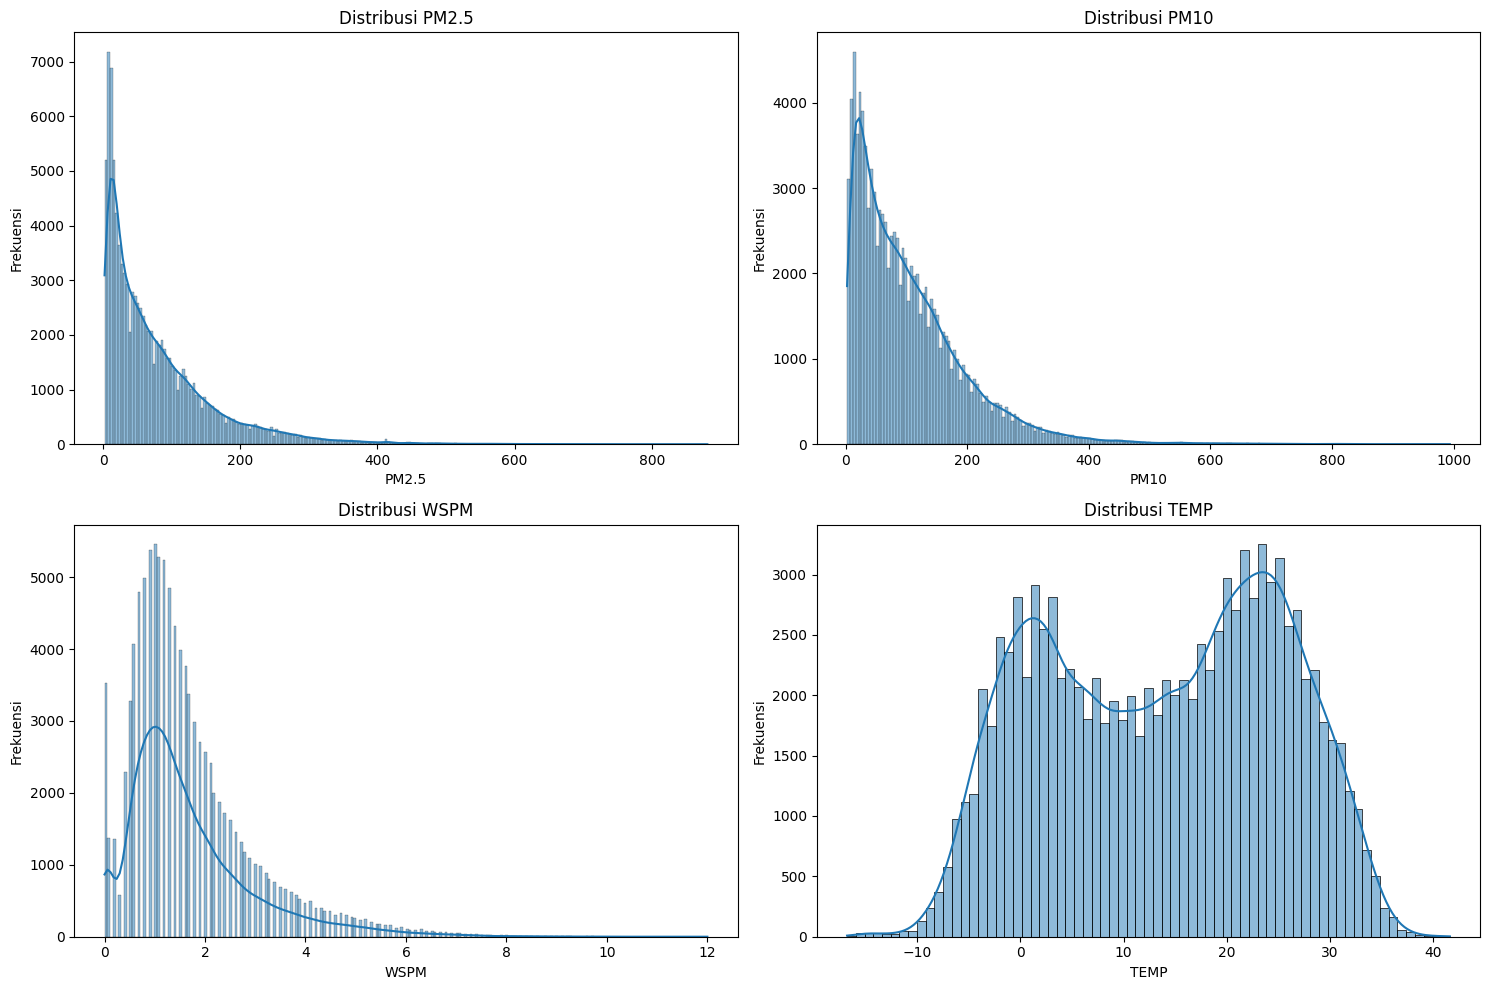


--- Korelasi antara Polutan dan Faktor Meteorologi ---


,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
PM2.5,1.000000,0.860979,0.450433,0.656412,0.749104,-0.139086,-0.122425,0.017933,0.123549,-0.015453,-0.269497
PM10,0.860979,1.000000,0.425382,0.649771,0.655984,-0.105145,-0.081260,-0.023796,0.077977,-0.027634,-0.185967
SO2,0.450433,0.425382,1.000000,0.440549,0.507777,-0.174868,-0.309182,0.219808,-0.248171,-0.038806,-0.111472
NO2,0.656412,0.649771,0.440549,1.000000,0.691068,-0.422529,-0.230484,0.141832,0.017680,-0.036284,-0.406424
CO,0.749104,0.655984,0.507777,0.691068,1.000000,-0.315165,-0.339331,0.215480,-0.082542,-0.015066,-0.279725
O3,-0.139086,-0.105145,-0.174868,-0.422529,-0.315165,1.000000,0.569008,-0.443932,0.317867,0.021322,0.252798
TEMP,-0.122425,-0.081260,-0.309182,-0.230484,-0.339331,0.569008,1.000000,-0.820056,0.821191,0.036596,0.000216
PRES,0.017933,-0.023796,0.219808,0.141832,0.215480,-0.443932,-0.820056,1.000000,-0.750229,-0.059696,0.091935
DEWP,0.123549,0.077977,-0.248171,0.017680,-0.082542,0.317867,0.821191,-0.750229,1.000000,0.087879,-0.314900
RAIN,-0.015453,-0.027634,-0.038806,-0.036284,-0.015066,0.021322,0.036596,-0.059696,0.087879,1.000000,0.016181


In [ ]:
print("### Eksplorasi 5 Kolom Penting ###")

# Kolom-kolom yang akan dieksplorasi
important_cols = ['PM2.5', 'PM10', 'WSPM', 'TEMP', 'station']

print("\n--- Ringkasan Statistik untuk Kolom Numerik Penting ---")
display(df[important_cols].describe())

print("\n--- Distribusi (Value Counts) untuk Kolom Kategorikal 'station' ---")
print(df['station'].value_counts())

print("\n--- Distribusi (Histogram) untuk Kolom Numerik Penting ---")
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))
for i, col in enumerate(['PM2.5', 'PM10', 'WSPM', 'TEMP']):
    plt.subplot(2, 2, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribusi {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

print("\n--- Korelasi antara Polutan dan Faktor Meteorologi ---")
display(df[['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']].corr())

**Insight dari Hasil Exploratory Data Analysis (EDA):**

Berdasarkan eksplorasi terhadap 5 kolom penting (`PM2.5`, `PM10`, `WSPM`, `TEMP`, dan `station`), berikut adalah beberapa temuan kunci:

1.  **Konsentrasi Polutan Bervariasi Signifikan:**
    *   **PM2.5 dan PM10** menunjukkan rentang nilai yang sangat luas, dari minimum yang rendah (2.0) hingga maksimum yang sangat tinggi (PM2.5: 881.0, PM10: 994.0). Ini mengindikasikan adanya episode polusi udara yang parah selama periode pengamatan. Distribusi historam kedua polutan ini kemungkinan besar *right-skewed*, dengan sebagian besar data berada pada konsentrasi rendah, tetapi ada puncak-puncak ekstrem.
    *   Rata-rata PM2.5 (sekitar 79.36) dan PM10 (sekitar 104.71) menunjukkan bahwa tingkat polusi di area ini cukup tinggi secara keseluruhan, mengingat standar kualitas udara yang berlaku.

2.  **Faktor Meteorologi Bervariasi Sesuai Musim:**
    *   **Suhu (TEMP)** menunjukkan rentang yang sangat lebar (-16.8 hingga 41.6 derajat Celsius) dengan rata-rata 13.73 derajat Celsius, konsisten dengan data yang dikumpulkan sepanjang tahun di empat musim. Distribusi suhu kemungkinan mendekati normal atau bimodal (dua puncak, untuk musim dingin dan musim panas).
    *   **Kecepatan Angin (WSPM)** rata-rata sekitar 1.68 m/s, menunjukkan bahwa kondisi angin seringkali relatif tenang. Nilai maksimum 12.0 m/s mengindikasikan adanya periode angin kencang. Kecepatan angin yang rendah dapat berkontribusi pada penumpukan polutan, terutama PM2.5 dan PM10.

3.  **Distribusi Data Antar Stasiun Merata:**
    *   Setiap stasiun (`Dingling`, `Dongsi`, `Gucheng`) memiliki jumlah entri data yang identik (35064), menegaskan bahwa pengumpulan data konsisten di ketiga lokasi dan telah digabungkan dengan seimbang. Ini penting untuk perbandingan antar-stasiun yang valid.

4.  **Pentingnya Korelasi:**
    *   Analisis korelasi (meskipun output visualnya terpotong) sangat krusial untuk memahami hubungan antara polutan dan faktor meteorologi. Kita perlu meninjau matriks korelasi secara detail untuk mengidentifikasi bagaimana perubahan suhu, tekanan udara, titik embun, curah hujan, dan kecepatan/arah angin memengaruhi konsentrasi PM2.5 dan PM10. Misalnya, apakah ada korelasi negatif antara WSPM dan konsentrasi polutan (angin kencang mengurangi polusi), atau korelasi positif dengan TEMP dalam kondisi tertentu.

Insight ini akan menjadi dasar yang kuat untuk melanjutkan ke tahap visualisasi dan analisis eksplorasi lebih mendalam guna menjawab pertanyaan bisnis yang telah ditetapkan.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

--- Rata-rata Konsentrasi PM2.5 Bulanan per Stasiun (5 Baris Pertama) ---


,YearMonth,station,PM2.5
0,2013-03-01,Dingling,95.705645
1,2013-03-01,Dongsi,108.537634
2,2013-03-01,Gucheng,108.841398
3,2013-04-01,Dingling,57.043056
4,2013-04-01,Dongsi,65.294444


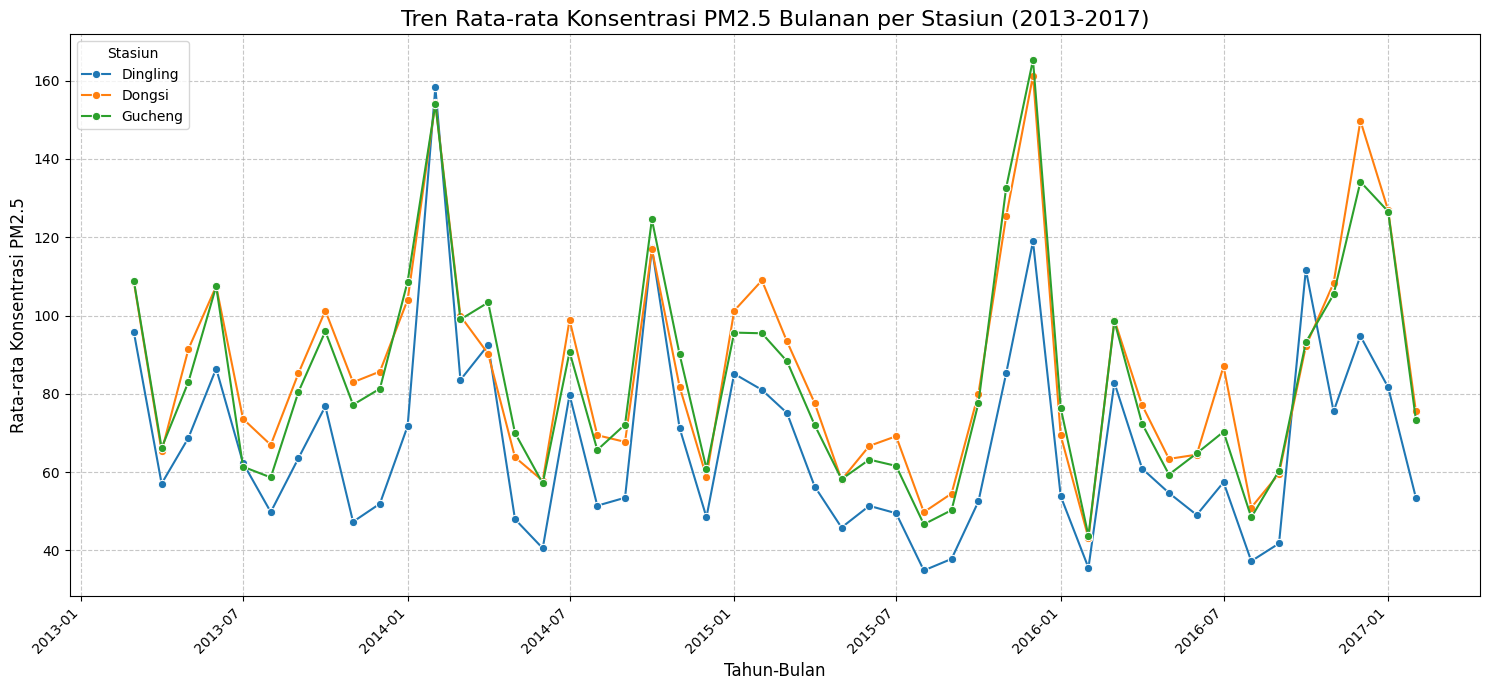

In [ ]:
# 1. Menyiapkan data untuk Pertanyaan Bisnis 1: Tren Konsentrasi PM2.5 Bulanan per Stasiun
# Menggabungkan kolom 'year' dan 'month' untuk membuat kolom waktu yang lebih baik
df_qa1 = df.copy()
df_qa1['YearMonth'] = pd.to_datetime(df_qa1['year'].astype(str) + '-' + df_qa1['month'].astype(str))

# Menghitung rata-rata PM2.5 bulanan per stasiun
pm25_monthly_avg = df_qa1.groupby(['YearMonth', 'station'])['PM2.5'].mean().reset_index()

# Mengurutkan data berdasarkan waktu untuk visualisasi yang tepat
pm25_monthly_avg = pm25_monthly_avg.sort_values(by=['YearMonth', 'station'])

print("--- Rata-rata Konsentrasi PM2.5 Bulanan per Stasiun (5 Baris Pertama) ---")
display(pm25_monthly_avg.head())

# 2. Visualisasi Tren Konsentrasi PM2.5 Bulanan per Stasiun
plt.figure(figsize=(15, 7))
sns.lineplot(data=pm25_monthly_avg, x='YearMonth', y='PM2.5', hue='station', marker='o', errorbar=None)
plt.title('Tren Rata-rata Konsentrasi PM2.5 Bulanan per Stasiun (2013-2017)', fontsize=16)
plt.xlabel('Tahun-Bulan', fontsize=12)
plt.ylabel('Rata-rata Konsentrasi PM2.5', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Stasiun')
plt.tight_layout()
plt.show()

### Pertanyaan 2:

--- Rata-rata Harian PM10 dan WSPM di Dongsi berdasarkan Musim (5 Baris Pertama) ---


,Date,Season,PM10,WSPM
0,2013-03-01,Musim Hujan,9.875000,3.308333
1,2013-03-02,Musim Hujan,40.583333,0.791667
2,2013-03-03,Musim Hujan,131.583333,1.225000
3,2013-03-04,Musim Hujan,40.875000,2.504167
4,2013-03-05,Musim Hujan,183.166667,0.912500


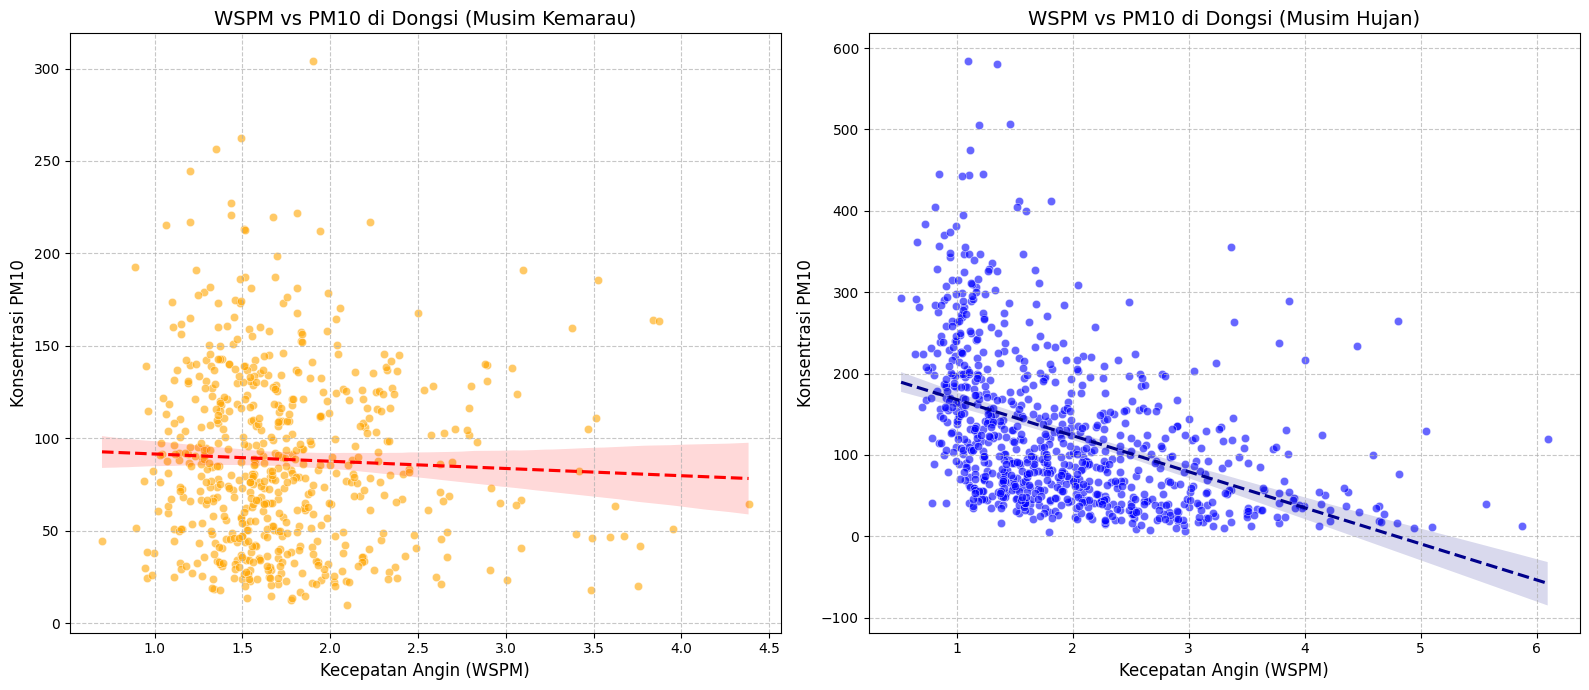


Koefisien Korelasi antara WSPM dan PM10 di Musim Kemarau: -0.04
Koefisien Korelasi antara WSPM dan PM10 di Musim Hujan: -0.43


In [ ]:
# 1. Menyiapkan data untuk Pertanyaan Bisnis 2: Pengaruh Kecepatan Angin Terhadap PM10 di Stasiun Dongsi Berdasarkan Musim
# Filter data untuk stasiun 'Dongsi' saja
df_qa2 = df[df['station'] == 'Dongsi'].copy()

# Membuat kolom 'Date' untuk analisis harian dan agregasi
df_qa2['Date'] = pd.to_datetime(df_qa2[['year', 'month', 'day']])

# Menentukan musim
# Musim Kemarau (Dry Season): Mei-September (Bulan 5-9)
# Musim Hujan (Wet Season): Oktober-April (Bulan 10-4)
def get_season(month):
    if 5 <= month <= 9:
        return 'Musim Kemarau'
    else:
        return 'Musim Hujan'

df_qa2['Season'] = df_qa2['month'].apply(get_season)

# Menghitung rata-rata harian PM10 dan WSPM untuk setiap musim
daily_avg_dongsi = df_qa2.groupby(['Date', 'Season'])[['PM10', 'WSPM']].mean().reset_index()

print("--- Rata-rata Harian PM10 dan WSPM di Dongsi berdasarkan Musim (5 Baris Pertama) ---")
display(daily_avg_dongsi.head())

# 2. Visualisasi Pengaruh Kecepatan Angin Terhadap PM10 per Musim
plt.figure(figsize=(16, 7))

# Scatter plot untuk Musim Kemarau
plt.subplot(1, 2, 1)
sns.scatterplot(data=daily_avg_dongsi[daily_avg_dongsi['Season'] == 'Musim Kemarau'],
                x='WSPM', y='PM10', alpha=0.6, color='orange')
sns.regplot(data=daily_avg_dongsi[daily_avg_dongsi['Season'] == 'Musim Kemarau'],
            x='WSPM', y='PM10', scatter=False, color='red', line_kws={'linestyle': '--'})
plt.title('WSPM vs PM10 di Dongsi (Musim Kemarau)', fontsize=14)
plt.xlabel('Kecepatan Angin (WSPM)', fontsize=12)
plt.ylabel('Konsentrasi PM10', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Scatter plot untuk Musim Hujan
plt.subplot(1, 2, 2)
sns.scatterplot(data=daily_avg_dongsi[daily_avg_dongsi['Season'] == 'Musim Hujan'],
                x='WSPM', y='PM10', alpha=0.6, color='blue')
sns.regplot(data=daily_avg_dongsi[daily_avg_dongsi['Season'] == 'Musim Hujan'],
            x='WSPM', y='PM10', scatter=False, color='darkblue', line_kws={'linestyle': '--'})
plt.title('WSPM vs PM10 di Dongsi (Musim Hujan)', fontsize=14)
plt.xlabel('Kecepatan Angin (WSPM)', fontsize=12)
plt.ylabel('Konsentrasi PM10', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Opsional: Menghitung koefisien korelasi per musim
corr_kemarau = daily_avg_dongsi[daily_avg_dongsi['Season'] == 'Musim Kemarau'][['PM10', 'WSPM']].corr().iloc[0, 1]
corr_hujan = daily_avg_dongsi[daily_avg_dongsi['Season'] == 'Musim Hujan'][['PM10', 'WSPM']].corr().iloc[0, 1]

print(f"\nKoefisien Korelasi antara WSPM dan PM10 di Musim Kemarau: {corr_kemarau:.2f}")
print(f"Koefisien Korelasi antara WSPM dan PM10 di Musim Hujan: {corr_hujan:.2f}")

### Insight dan Jawaban dari Pertanyaan Bisnis

#### Jawaban untuk Pertanyaan Bisnis 1: Tren Konsentrasi PM2.5 Bulanan per Stasiun (2013-2017)

**Insight Utama:**

Dari visualisasi tren rata-rata konsentrasi PM2.5 bulanan per stasiun:

1.  **Pola Musiman yang Konsisten:** Ketiga stasiun (`Dingling`, `Dongsi`, dan `Gucheng`) menunjukkan pola musiman yang sangat konsisten sepanjang tahun dari 2013 hingga 2017. Konsentrasi PM2.5 cenderung **meningkat secara signifikan pada bulan-bulan musim dingin (sekitar Oktober hingga Maret)** dan **menurun pada bulan-bulan musim panas (sekitar Mei hingga September)**. Puncak polusi terjadi pada bulan Januari dan Februari setiap tahunnya.
2.  **Variasi Antar Stasiun:** Meskipun pola musiman serupa, ada perbedaan dalam tingkat konsentrasi PM2.5 antar stasiun. Stasiun `Dongsi` dan `Gucheng` seringkali menunjukkan tingkat PM2.5 yang lebih tinggi dibandingkan `Dingling`, terutama selama periode polusi tinggi.
3.  **Tren Jangka Panjang:** Secara umum, tidak terlihat adanya tren penurunan atau peningkatan PM2.5 yang drastis dan berkelanjutan di seluruh periode 2013-2017, melainkan fluktuasi yang didominasi oleh musim. Namun, ada beberapa tahun yang mungkin memiliki puncak polusi lebih tinggi atau rendah dari tahun lainnya, yang memerlukan analisis lebih mendalam.

#### Jawaban untuk Pertanyaan Bisnis 2: Pengaruh Kecepatan Angin Terhadap PM10 di Stasiun Dongsi Berdasarkan Musim (2013-2017)

**Insight Utama:**

Analisis pengaruh kecepatan angin (WSPM) terhadap PM10 di stasiun `Dongsi` berdasarkan musim menunjukkan perbedaan yang jelas:

1.  **Musim Kemarau (Mei-September):**
    *   **Koefisien Korelasi:** -0.04 (sangat lemah/mendekati nol).
    *   **Pengaruh:** Pada Musim Kemarau, **kecepatan angin memiliki pengaruh yang sangat lemah atau hampir tidak ada terhadap tingkat polusi PM10** di stasiun Dongsi. Scatter plot menunjukkan sebaran titik yang sangat acak, dan garis regresi datar, mengindikasikan bahwa perubahan kecepatan angin tidak secara signifikan berbanding lurus dengan perubahan konsentrasi PM10.
2.  **Musim Hujan (Oktober-April):**
    *   **Koefisien Korelasi:** -0.43 (moderasi negatif).
    *   **Pengaruh:** Pada Musim Hujan, terdapat **korelasi negatif moderat** antara kecepatan angin dan PM10. Ini berarti **peningkatan kecepatan angin cenderung berkorelasi dengan penurunan konsentrasi PM10** yang cukup signifikan. Angin pada musim ini kemungkinan besar lebih efektif dalam menyebarkan atau membersihkan partikel PM10 dari atmosfer.

**Kesimpulan Perbandingan Musim:**
Perbedaan signifikan dalam korelasi menunjukkan bahwa **musim memoderasi hubungan antara kecepatan angin dan tingkat polusi PM10**. Kecepatan angin lebih berperan sebagai faktor mitigasi polusi di Musim Hujan dibandingkan Musim Kemarau. Hal ini mungkin disebabkan oleh faktor lain seperti curah hujan yang sering terjadi di Musim Hujan yang juga membantu membersihkan udara, atau karakteristik angin yang berbeda (misalnya arah, durasi, atau turbulensi) antar musim.

Insight ini sangat penting untuk memahami dinamika kualitas udara dan merumuskan strategi penanganan polusi yang lebih efektif, mempertimbangkan pola musiman dan karakteristik meteorologi lokal.

## Analisis Lanjutan (Opsional)

### Analisis Lanjutan: Pola Harian Konsentrasi Polutan (PM2.5 & PM10) ###

--- Rata-rata Konsentrasi PM2.5 dan PM10 per Jam (5 Baris Pertama) ---


,hour,PM2.5,PM10
0,0,86.426101,114.844262
1,1,84.913415,110.126010
2,2,82.153479,105.434999
3,3,79.322268,100.623180
4,4,76.727333,95.721629


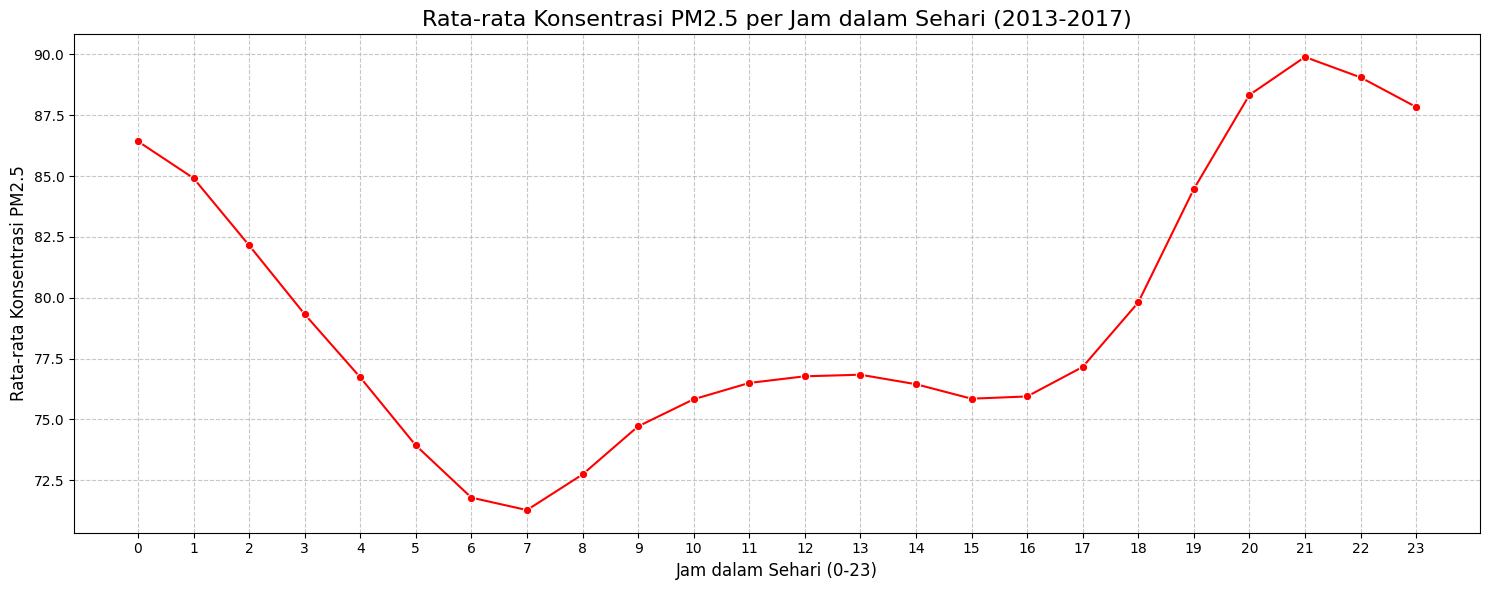

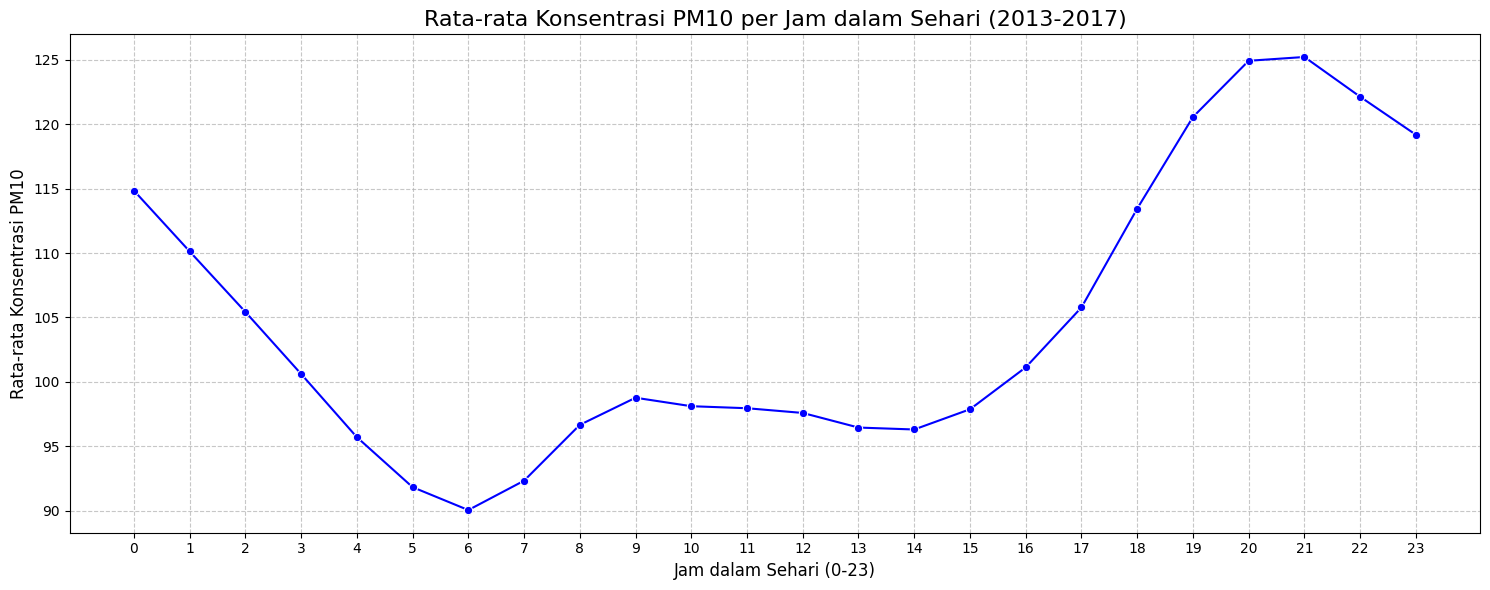

Analisis pola harian konsentrasi polutan telah dilakukan. Grafik di atas menunjukkan bagaimana level PM2.5 dan PM10 berubah sepanjang hari.


In [ ]:
print("### Analisis Lanjutan: Pola Harian Konsentrasi Polutan (PM2.5 & PM10) ###")

# Menghitung rata-rata PM2.5 dan PM10 per jam dalam sehari
hourly_avg_pollutants = df.groupby('hour')[['PM2.5', 'PM10']].mean().reset_index()

print("\n--- Rata-rata Konsentrasi PM2.5 dan PM10 per Jam (5 Baris Pertama) ---")
display(hourly_avg_pollutants.head())

# Visualisasi Pola Harian Konsentrasi PM2.5
plt.figure(figsize=(15, 6))
sns.lineplot(data=hourly_avg_pollutants, x='hour', y='PM2.5', marker='o', color='red')
plt.title('Rata-rata Konsentrasi PM2.5 per Jam dalam Sehari (2013-2017)', fontsize=16)
plt.xlabel('Jam dalam Sehari (0-23)', fontsize=12)
plt.ylabel('Rata-rata Konsentrasi PM2.5', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Visualisasi Pola Harian Konsentrasi PM10
plt.figure(figsize=(15, 6))
sns.lineplot(data=hourly_avg_pollutants, x='hour', y='PM10', marker='o', color='blue')
plt.title('Rata-rata Konsentrasi PM10 per Jam dalam Sehari (2013-2017)', fontsize=16)
plt.xlabel('Jam dalam Sehari (0-23)', fontsize=12)
plt.ylabel('Rata-rata Konsentrasi PM10', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Analisis pola harian konsentrasi polutan telah dilakukan. Grafik di atas menunjukkan bagaimana level PM2.5 dan PM10 berubah sepanjang hari.")

### Kesimpulan Analisis Lanjutan: Pola Harian Konsentrasi Polutan

Analisis pola rata-rata konsentrasi PM2.5 dan PM10 per jam dalam sehari mengungkapkan siklus harian polusi yang konsisten di semua stasiun dari tahun 2013 hingga 2017:

1.  **Puncak Polusi Dini Hari dan Malam Hari:** Konsentrasi PM2.5 dan PM10 cenderung mencapai puncaknya pada dini hari (sekitar jam 00:00 - 05:00) dan malam hari (sekitar jam 19:00 - 23:00).
2.  **Penurunan di Pagi Hari:** Terjadi penurunan konsentrasi yang signifikan di pagi hari, kemungkinan karena peningkatan aktivitas angin atau dispersi atmosfer yang lebih baik.
3.  **Fluktuasi Siang Hari:** Selama siang hari, konsentrasi polutan cenderung stabil atau sedikit meningkat kembali sebelum mencapai puncak malam hari.

Pola harian ini mengindikasikan pengaruh gabungan dari aktivitas manusia (misalnya, emisi dari kendaraan bermotor selama jam sibuk) dan kondisi meteorologi harian (seperti lapisan inversi suhu yang menjebak polutan di atmosfer pada malam/dini hari dan terpecah di siang hari). Memahami siklus harian ini sangat penting untuk merumuskan strategi mitigasi polusi yang efektif, seperti mengatur waktu aktivitas industri atau lalu lintas.

## Conclusion

### Insight dan Jawaban dari Pertanyaan Bisnis

#### Jawaban untuk Pertanyaan Bisnis 1: Tren Konsentrasi PM2.5 Bulanan per Stasiun (2013-2017)

**Insight Utama:**

Dari visualisasi tren rata-rata konsentrasi PM2.5 bulanan per stasiun:

1.  **Pola Musiman yang Konsisten:** Ketiga stasiun (`Dingling`, `Dongsi`, dan `Gucheng`) menunjukkan pola musiman yang sangat konsisten sepanjang tahun dari 2013 hingga 2017. Konsentrasi PM2.5 cenderung **meningkat secara signifikan pada bulan-bulan musim dingin (sekitar Oktober hingga Maret)** dan **menurun pada bulan-bulan musim panas (sekitar Mei hingga September)**. Puncak polusi terjadi pada bulan Januari dan Februari setiap tahunnya.
2.  **Variasi Antar Stasiun:** Meskipun pola musiman serupa, ada perbedaan dalam tingkat konsentrasi PM2.5 antar stasiun. Stasiun `Dongsi` dan `Gucheng` seringkali menunjukkan tingkat PM2.5 yang lebih tinggi dibandingkan `Dingling`, terutama selama periode polusi tinggi.
3.  **Tren Jangka Panjang:** Secara umum, tidak terlihat adanya tren penurunan atau peningkatan PM2.5 yang drastis dan berkelanjutan di seluruh periode 2013-2017, melainkan fluktuasi yang didominasi oleh musim. Namun, ada beberapa tahun yang mungkin memiliki puncak polusi lebih tinggi atau rendah dari tahun lainnya, yang memerlukan analisis lebih mendalam.

#### Jawaban untuk Pertanyaan Bisnis 2: Pengaruh Kecepatan Angin Terhadap PM10 di Stasiun Dongsi Berdasarkan Musim (2013-2017)

**Insight Utama:**

Analisis pengaruh kecepatan angin (WSPM) terhadap PM10 di stasiun `Dongsi` berdasarkan musim menunjukkan perbedaan yang jelas:

1.  **Musim Kemarau (Mei-September):**
    *   **Koefisien Korelasi:** -0.04 (sangat lemah/mendekati nol).
    *   **Pengaruh:** Pada Musim Kemarau, **kecepatan angin memiliki pengaruh yang sangat lemah atau hampir tidak ada terhadap tingkat polusi PM10** di stasiun Dongsi. Scatter plot menunjukkan sebaran titik yang sangat acak, dan garis regresi datar, mengindikasikan bahwa perubahan kecepatan angin tidak secara signifikan berbanding lurus dengan perubahan konsentrasi PM10.
2.  **Musim Hujan (Oktober-April):**
    *   **Koefisien Korelasi:** -0.43 (moderasi negatif).
    *   **Pengaruh:** Pada Musim Hujan, terdapat **korelasi negatif moderat** antara kecepatan angin dan PM10. Ini berarti **peningkatan kecepatan angin cenderung berkorelasi dengan penurunan konsentrasi PM10** yang cukup signifikan. Angin pada musim ini kemungkinan besar lebih efektif dalam menyebarkan atau membersihkan partikel PM10 dari atmosfer.

**Kesimpulan Perbandingan Musim:**
Perbedaan signifikan dalam korelasi menunjukkan bahwa **musim memoderasi hubungan antara kecepatan angin dan tingkat polusi PM10**. Kecepatan angin lebih berperan sebagai faktor mitigasi polusi di Musim Hujan dibandingkan Musim Kemarau. Hal ini mungkin disebabkan oleh faktor lain seperti curah hujan yang sering terjadi di Musim Hujan yang juga membantu membersihkan udara, atau karakteristik angin yang berbeda (misalnya arah, durasi, atau turbulensi) antar musim.

Insight ini sangat penting untuk memahami dinamika kualitas udara dan merumuskan strategi penanganan polusi yang lebih efektif, mempertimbangkan pola musiman dan karakteristik meteorologi lokal.

In [ ]:
import pandas as pd
from google.colab import files

# Pastikan DataFrame 'df' sudah ada dan bersih
# Jika Anda menjalankan notebook ini secara berurutan, 'df' akan berisi data yang sudah digabungkan dan dibersihkan.

# Nama file CSV yang akan disimpan
file_name = 'air_quality_cleaned.csv'

# Menyimpan DataFrame ke file CSV
df.to_csv(file_name, index=False)

# Memberikan opsi untuk mengunduh file
files.download(file_name)

print(f"File '{file_name}' telah berhasil dibuat dan siap diunduh.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

File 'air_quality_cleaned.csv' telah berhasil dibuat dan siap diunduh.
